# Analysis of the Results

**Jakob Balkovec**

In [36]:
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(
    style="whitegrid",
    context="paper",
    font_scale=1.15
)

plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "lines.linewidth": 2.2,
    "lines.markersize": 7,
    "grid.alpha": 0.25,
    "grid.linestyle": "--"
})

FIG_DIR = Path("paper/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

palette = {
    "Bubble Sort": "#C44E52",
    "std::sort": "#4C72B0",
    "Row-major": "#55A868",
    "Column-major": "#8172B2"
}

size_map = {
    "small": 1000,
    "medium": 10000,
    "large": 100000
}

### Sorting
---

In [3]:
sorting = pd.read_csv("../results/sorting_results.csv")
sorting.head()

,dataset,bubble_sort,std_sort
0,data/random_small.txt,0.042610,0.000200
1,data/random_medium.txt,1.932710,0.000829
2,data/random_large.txt,8.400370,0.001715
3,data/sorted_small.txt,0.017390,0.000012
4,data/sorted_medium.txt,0.425606,0.000043


In [4]:
sorting["dataset_type"] = sorting["dataset"].str.extract(r"(random|sorted|reverse)")
sorting["dataset_size"] = sorting["dataset"].str.extract(r"(small|medium|large)")

size_order = ["small", "medium", "large"]
sorting["dataset_size"] = pd.Categorical(sorting["dataset_size"], categories=size_order, ordered=True)

sorting.head()

,dataset,bubble_sort,std_sort,dataset_type,dataset_size
0,data/random_small.txt,0.042610,0.000200,random,small
1,data/random_medium.txt,1.932710,0.000829,random,medium
2,data/random_large.txt,8.400370,0.001715,random,large
3,data/sorted_small.txt,0.017390,0.000012,sorted,small
4,data/sorted_medium.txt,0.425606,0.000043,sorted,medium


In [5]:
sorting_summary = (
    sorting
    .groupby(["dataset_type", "dataset_size"], observed=False)
    .agg(
        bubble_mean=("bubble_sort", "mean"),
        bubble_std=("bubble_sort", "std"),
        std_mean=("std_sort", "mean"),
        std_std=("std_sort", "std")
    )
    .reset_index()
)

sorting_summary["speedup_ratio"] = sorting_summary["bubble_mean"] / sorting_summary["std_mean"]
sorting_summary

,dataset_type,dataset_size,bubble_mean,bubble_std,std_mean,std_std,speedup_ratio
0,random,small,0.028788,0.002088,0.000163,1.405187e-05,176.459482
1,random,medium,1.900443,0.038142,0.000855,8.102070e-05,2223.174013
2,random,large,8.273913,0.153435,0.001727,4.261227e-05,4791.805729
3,reverse,small,0.017021,0.001162,0.000018,3.579126e-06,970.434447
4,reverse,medium,0.422713,0.010602,0.000079,5.055507e-06,5326.690822
5,reverse,large,1.692640,0.033996,0.000155,5.923040e-06,10893.373449
6,sorted,small,0.016614,0.000505,0.000009,7.434140e-07,1775.289901
7,sorted,medium,0.418278,0.009462,0.000046,4.163751e-06,9187.390286
8,sorted,large,1.673796,0.035563,0.000090,4.064044e-06,18554.098217


In [44]:
sorting_summary = (
    sorting
    .groupby(["dataset_type", "dataset_size"], observed=False)
    .agg(
        bubble_mean=("bubble_sort", "mean"),
        bubble_std=("bubble_sort", "std"),
        std_mean=("std_sort", "mean"),
        std_std=("std_sort", "std")
    )
    .reset_index()
)

sorting_summary["speedup_ratio"] = sorting_summary["bubble_mean"] / sorting_summary["std_mean"]
sorting_summary["n"] = sorting_summary["dataset_size"].map(size_map)
print(sorting_summary)

  dataset_type dataset_size  bubble_mean  bubble_std  std_mean       std_std  \
0       random        small     0.028788    0.002088  0.000163  1.405187e-05   
1       random       medium     1.900443    0.038142  0.000855  8.102070e-05   
2       random        large     8.273913    0.153435  0.001727  4.261227e-05   
3      reverse        small     0.017021    0.001162  0.000018  3.579126e-06   
4      reverse       medium     0.422713    0.010602  0.000079  5.055507e-06   
5      reverse        large     1.692640    0.033996  0.000155  5.923040e-06   
6       sorted        small     0.016614    0.000505  0.000009  7.434140e-07   
7       sorted       medium     0.418278    0.009462  0.000046  4.163751e-06   
8       sorted        large     1.673796    0.035563  0.000090  4.064044e-06   

   speedup_ratio       n  
0     176.459482    1000  
1    2223.174013   10000  
2    4791.805729  100000  
3     970.434447    1000  
4    5326.690822   10000  
5   10893.373449  100000  
6    1775.

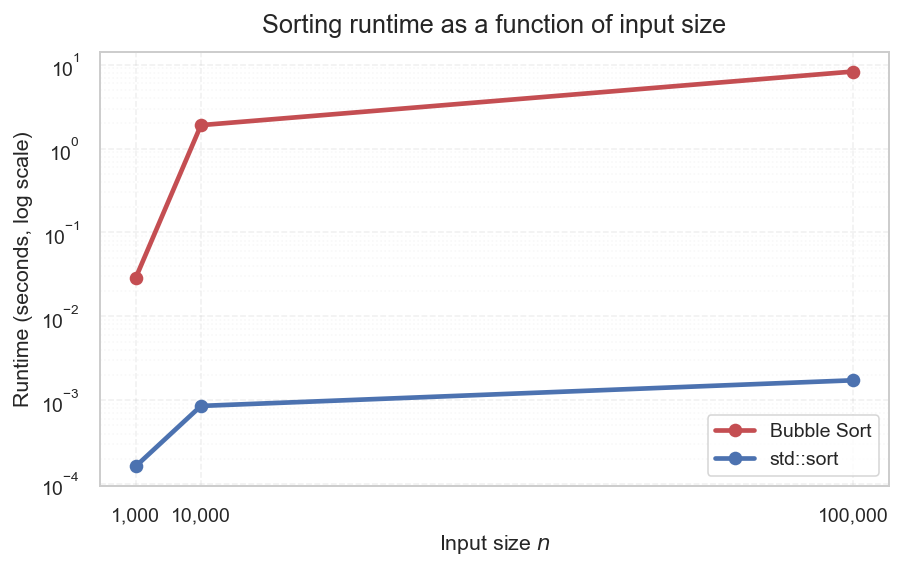

In [45]:
df = sorting_summary[sorting_summary["dataset_type"] == "random"].copy()
df = df.sort_values("n")

fig, ax = plt.subplots(figsize=(6.6, 4.2))

ax.plot(
    df["n"], df["bubble_mean"],
    marker="o", linewidth=2.4, markersize=7,
    color=palette["Bubble Sort"],
    label="Bubble Sort"
)

ax.plot(
    df["n"], df["std_mean"],
    marker="o", linewidth=2.4, markersize=7,
    color=palette["std::sort"],
    label="std::sort"
)

ax.set_yscale("log")

ax.set_xlabel("Input size $n$")
ax.set_ylabel("Runtime (seconds, log scale)")
ax.set_title("Sorting runtime as a function of input size", pad=10)

ax.set_xticks(df["n"])
ax.set_xticklabels([f"{int(x):,}" for x in df["n"]])

ax.grid(True, which="major", linestyle="--", alpha=0.3)
ax.grid(True, which="minor", linestyle=":", alpha=0.15)

ax.legend(frameon=True)

plt.tight_layout()
plt.savefig(FIG_DIR / "sorting_runtime_clean.png", dpi=300, bbox_inches="tight")
plt.show()

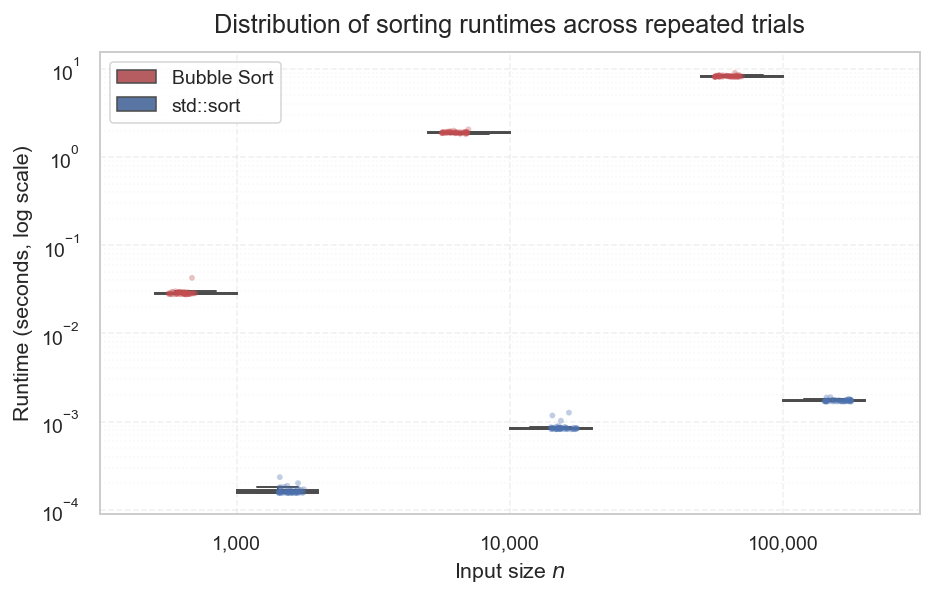

In [47]:
df = sorting[sorting["dataset_type"] == "random"].copy()

df_long = df.melt(
    id_vars=["n"],
    value_vars=["bubble_sort", "std_sort"],
    var_name="algorithm",
    value_name="runtime"
)

algo_map = {
    "bubble_sort": "Bubble Sort",
    "std_sort": "std::sort"
}
df_long["algorithm"] = df_long["algorithm"].map(algo_map)

fig, ax = plt.subplots(figsize=(6.8, 4.4))

sns.boxplot(
    data=df_long,
    x="n",
    y="runtime",
    hue="algorithm",
    palette=palette,
    width=0.6,
    fliersize=0,
    ax=ax
)

sns.stripplot(
    data=df_long,
    x="n",
    y="runtime",
    hue="algorithm",
    dodge=True,
    palette=palette,
    alpha=0.35,
    size=3,
    ax=ax
)

ax.set_yscale("log")
ax.set_xlabel("Input size $n$")
ax.set_ylabel("Runtime (seconds, log scale)")
ax.set_title("Distribution of sorting runtimes across repeated trials", pad=10)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:2], labels[:2], frameon=True, title="")

ax.set_xticks(range(len(sorted(df_long["n"].unique()))))
ax.set_xticklabels([f"{int(x):,}" for x in sorted(df_long["n"].unique())])

ax.grid(True, which="major", linestyle="--", alpha=0.3)
ax.grid(True, which="minor", linestyle=":", alpha=0.15)

plt.tight_layout()
plt.savefig(FIG_DIR / "sorting_distribution_clean.png", dpi=300, bbox_inches="tight")
plt.show()

### Cache Performance
---

In [10]:
cache = pd.read_csv("../results/cache_results.csv")
cache.head()

,matrix_size,row_major,column_major
0,1024x1024,0.001186,0.002904
1,2048x2048,0.004402,0.019010
2,4096x4096,0.017109,0.091420
3,1024x1024,0.000916,0.002156
4,2048x2048,0.004195,0.017115


In [11]:
cache["N"] = cache["matrix_size"].str.extract(r"(\d+)").astype(int)
cache.head()

,matrix_size,row_major,column_major,N
0,1024x1024,0.001186,0.002904,1024
1,2048x2048,0.004402,0.019010,2048
2,4096x4096,0.017109,0.091420,4096
3,1024x1024,0.000916,0.002156,1024
4,2048x2048,0.004195,0.017115,2048


In [43]:
cache_summary = (
    cache
    .groupby("N")
    .agg(
        row_mean=("row_major", "mean"),
        row_std=("row_major", "std"),
        col_mean=("column_major", "mean"),
        col_std=("column_major", "std")
    )
    .reset_index()
)

cache_summary["slowdown_ratio"] = cache_summary["col_mean"] / cache_summary["row_mean"]
print(cache_summary)

      N  row_mean   row_std  col_mean   col_std  slowdown_ratio
0  1024  0.001017  0.000520  0.002527  0.001786        2.485682
1  2048  0.004204  0.000297  0.017667  0.001067        4.202776
2  4096  0.016051  0.000765  0.092735  0.002838        5.777379


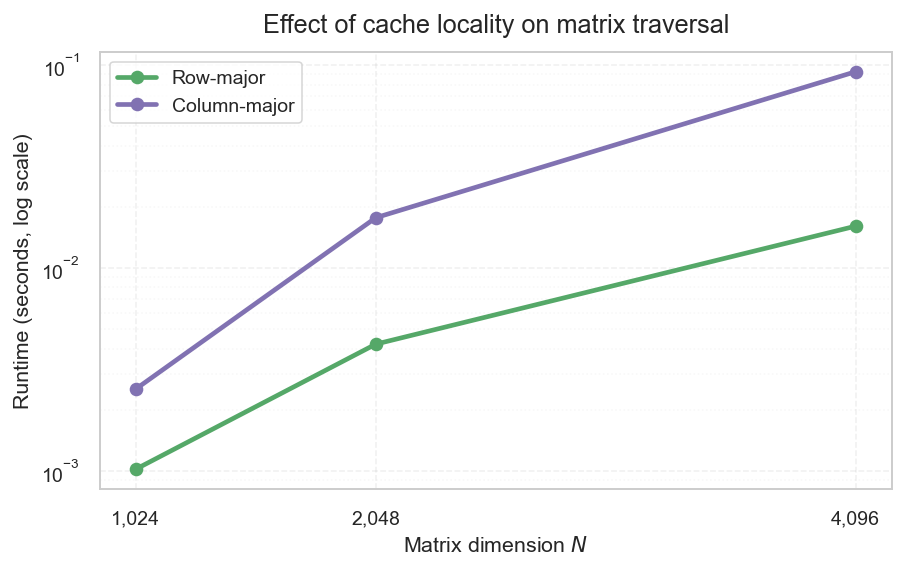

In [ ]:
df = cache_summary.copy().sort_values("N")

fig, ax = plt.subplots(figsize=(6.6, 4.2))

ax.plot(
    df["N"], df["row_mean"],
    marker="o", linewidth=2.4, markersize=7,
    color=palette["Row-major"],
    label="Row-major"
)

ax.plot(
    df["N"], df["col_mean"],
    marker="o", linewidth=2.4, markersize=7,
    color=palette["Column-major"],
    label="Column-major"
)

ax.set_yscale("log")

ax.set_xlabel("Matrix dimension $N$")
ax.set_ylabel("Runtime (seconds, log scale)")
ax.set_title("Effect of cache locality on matrix traversal", pad=10)

ax.set_xticks(df["N"])
ax.set_xticklabels([f"{int(x):,}" for x in df["N"]])

ax.grid(True, which="major", linestyle="--", alpha=0.3)
ax.grid(True, which="minor", linestyle=":", alpha=0.15)

ax.legend(frameon=True)

plt.tight_layout()
plt.savefig(FIG_DIR / "cache_runtime_clean.png", dpi=300, bbox_inches="tight")
plt.show()

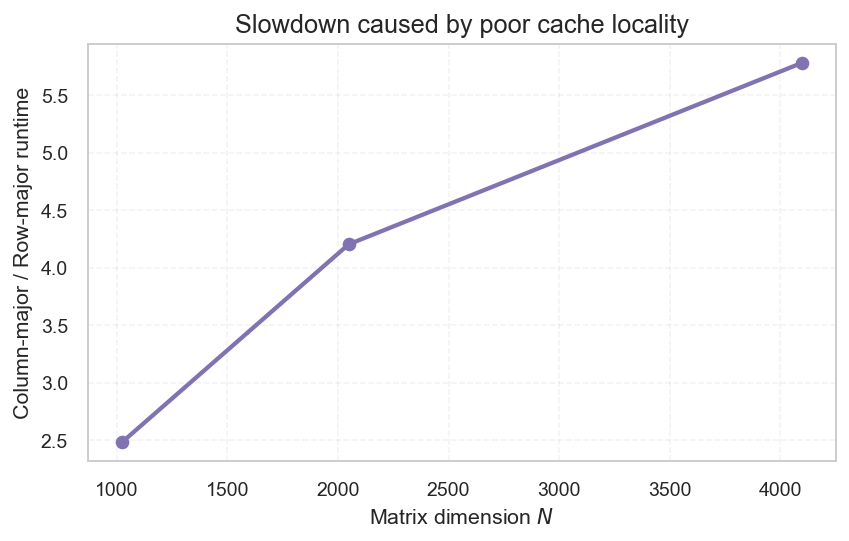

In [40]:
plt.figure(figsize=(6.2, 4.0))

plt.plot(
    cache_summary["N"], cache_summary["slowdown_ratio"],
    marker="o", color=palette["Column-major"]
)

plt.xlabel("Matrix dimension $N$")
plt.ylabel("Column-major / Row-major runtime")
plt.title("Slowdown caused by poor cache locality")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig(FIG_DIR / "cache_slowdown_ratio.png")
plt.show()

### Notes
---

In [ ]:
sorting_summary.to_csv("../results/sorting_summary.csv", index=False)
cache_summary.to_csv("../results/cache_summary.csv", index=False)